In [29]:
# Let's add the root directory to our system search path to allow imports from sibling directories.
import os, sys
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LOG_DIR = Path("../logs/")
LOG_FILE = sorted(Path("../logs").glob("*.log"))[-1]

In [31]:
def get_log_data():
    data = {
        "lr": [],
        "temp": [],
        "m": [],
        "wd": [],
        "dino": [],
        "ibot": [],
        "gram": [],
        "koleo": []
    }

    lines = None
    with open(LOG_FILE, 'r') as f:
        lines = f.readlines()

    for line in lines:
        if "Epoch" not in line:
            continue

        l = line.split("lr: ")[-1]
        l = l.split(',')

        lr = float(l[0])
        data["lr"].append(lr)

        temp = float(l[1].split(': ')[-1])
        data["temp"].append(temp)

        m = float(l[2].split(': ')[-1])
        data["m"].append(m)

        wd = float(l[3].split(': ')[-1])
        data["wd"].append(wd)

        dino = float(l[4].split(': ')[-1])
        data["dino"].append(dino)

        ibot = float(l[5].split(': ')[-1])
        data["ibot"].append(ibot)

        gram = float(l[6].split(': ')[-1])
        data["gram"].append(gram)

        koleo = float(l[7].split(': ')[-1])
        data["koleo"].append(koleo)

    return data


def show_figure(graphs, labels, name, threshold=None):
    plt.figure(figsize=(12, 6))

    # Convert lists to numpy arrays for easier plotting
    iters = range(len(graphs[0]))

    # Draw a dotted red line at threshold
    if threshold is not None:
        plt.axhline(y=threshold, color='red', linestyle=':')

    # Plot DINO and Ibot
    for i in range(len(graphs)):
        plt.plot(iters, graphs[i], label=labels[i])

    # Add labels and title
    plt.title(name)
    plt.xlabel('Iterations')
    plt.ylabel('Values')
    plt.legend()
    plt.grid()

    # Show the plot
    plt.show()

In [32]:
log_data = get_log_data()

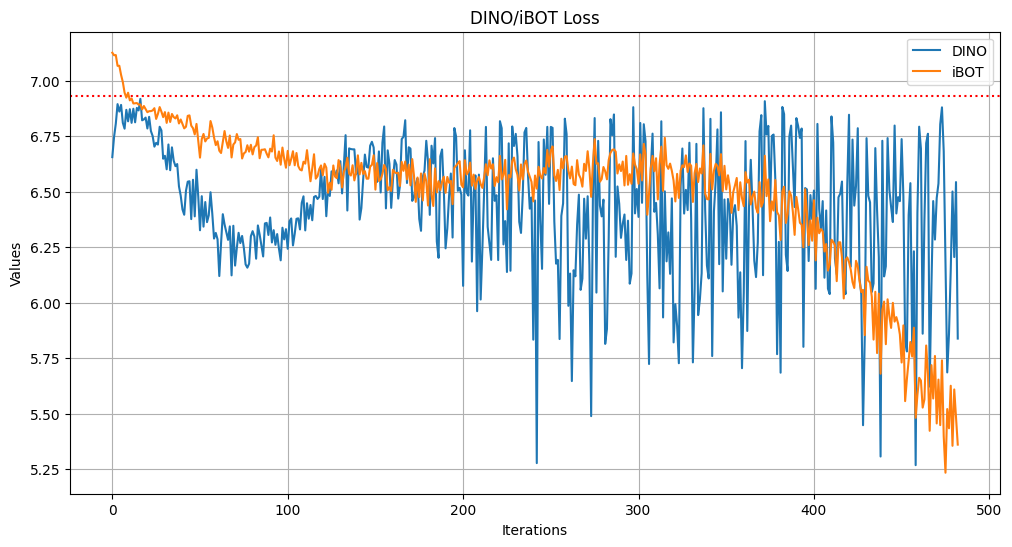

In [33]:
show_figure((log_data['dino'], log_data['ibot']), ('DINO', 'iBOT'), "DINO/iBOT Loss", np.log(1024))

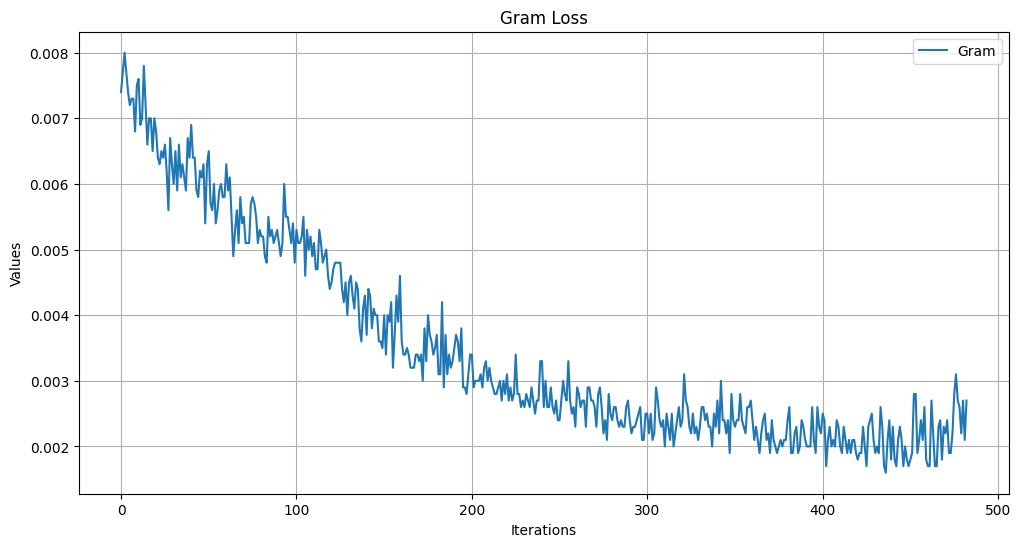

In [34]:
show_figure((log_data['gram'],), ('Gram',), "Gram Loss")

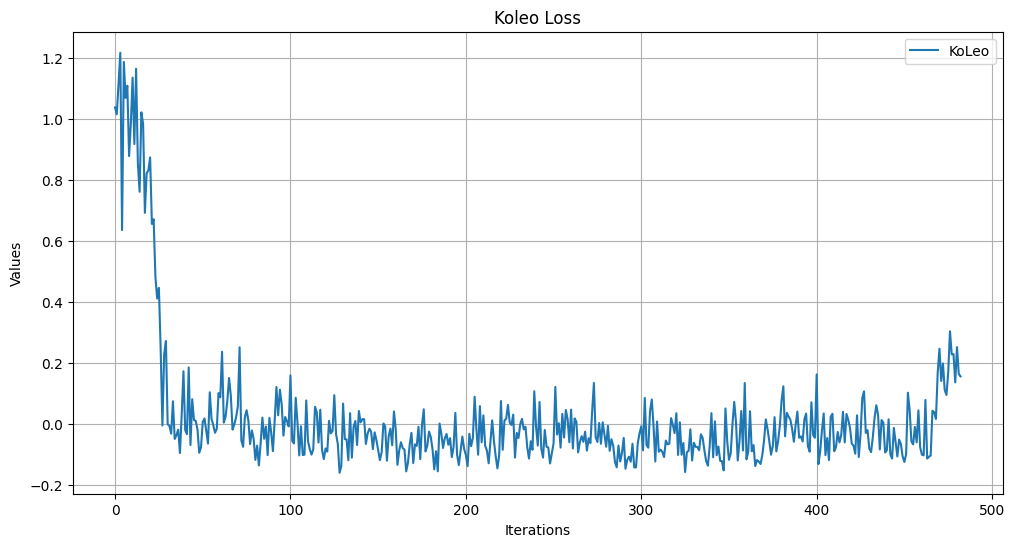

In [35]:
show_figure((log_data['koleo'],), ('KoLeo',), "Koleo Loss")
